In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.colors as colors
import xarray as xr
import geopandas as gpd
import contextily as cx
import numpy as np
from scores.continuous import kge
from val_utils import *
sns.set_theme()

In [17]:
csi_in = xr.open_dataset("../data/CSI_inputdata.nc")
csii_in = xr.open_dataset("../data/CSII_inputdata.nc")
csiii_in = xr.open_dataset("../data/CSIII_inputdata.nc")
csiv_in = xr.open_dataset("../data/CSIV_inputdata.nc")

csi_aoi = gpd.read_file("../data/CSI_aoi.shp")
csii_aoi = gpd.read_file("../data/CSII_aoi.shp")
csiii_aoi = gpd.read_file("../data/CSIII_aoi.shp")
csiv_aoi = gpd.read_file("../data/CSIV_aoi.shp")

In [18]:

csi_in = csi_in.rio.write_crs("EPSG:4326")
csii_in = csii_in.rio.write_crs("EPSG:4326")
csiii_in = csiii_in.rio.write_crs("EPSG:4326")
csiv_in = csiv_in.rio.write_crs("EPSG:4326")


csi_ore = csi_in["ore"].rio.set_spatial_dims(x_dim="lon", y_dim="lat")
csii_ore = csii_in["ore"].rio.set_spatial_dims(x_dim="lon", y_dim="lat")
csiii_ore = csiii_in["ore"].rio.set_spatial_dims(x_dim="lon", y_dim="lat")
csiv_ore = csiv_in["ore"].rio.set_spatial_dims(x_dim="lon", y_dim="lat")

from shapely.geometry import mapping

csi_aoi = csi_aoi.to_crs(csi_in.rio.crs)
csii_aoi = csii_aoi.to_crs(csii_in.rio.crs)
csiii_aoi = csiii_aoi.to_crs(csiii_in.rio.crs)
csiv_aoi = csiv_aoi.to_crs(csiv_in.rio.crs)

geoms_i = [mapping(geom) for geom in csi_aoi.geometry]
geoms_ii = [mapping(geom) for geom in csii_aoi.geometry]
geoms_iii = [mapping(geom) for geom in csiii_aoi.geometry]
geoms_iv = [mapping(geom) for geom in csiv_aoi.geometry]

csi_ore = csi_ore.rio.clip(
    geoms_i,
    csi_aoi.crs,
    drop=True,
    all_touched=True
)

csii_ore = csii_ore.rio.clip(
    geoms_ii,
    csii_aoi.crs,
    drop=True,
    all_touched=True
)

csiii_ore = csiii_ore.rio.clip(
    geoms_iii,
    csiii_aoi.crs,
    drop=True,
    all_touched=True
)

csiv_ore = csiv_ore.rio.clip(
    geoms_iv,
    csiv_aoi.crs,
    drop=True,
    all_touched=True
)


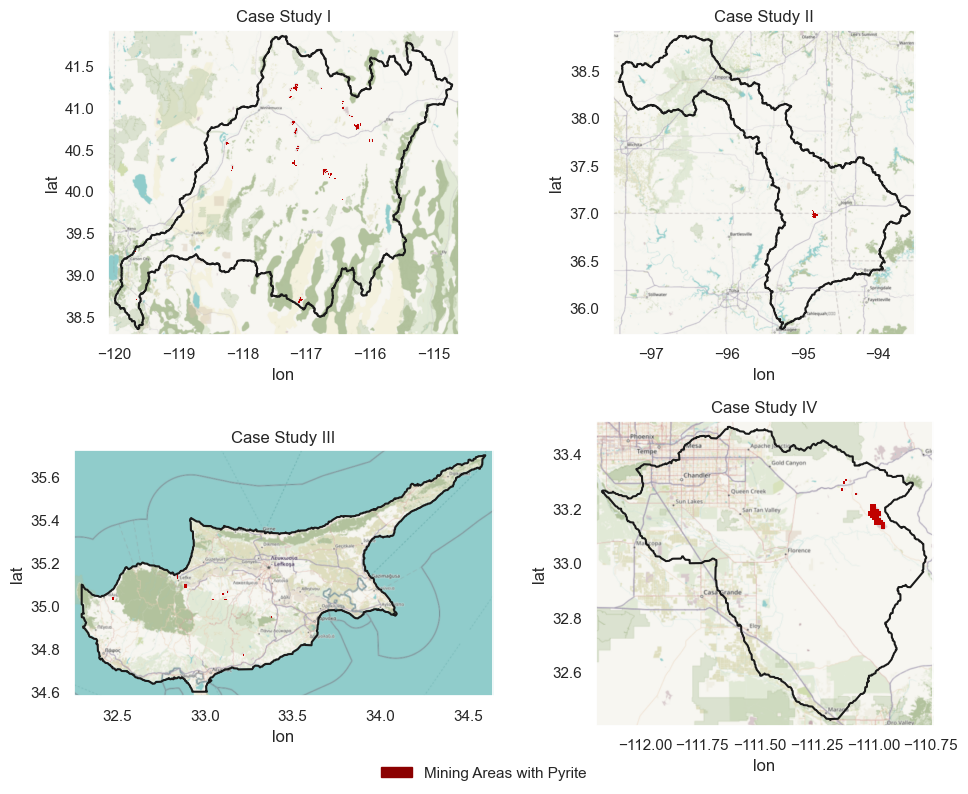

In [19]:
red_patch = mpatches.Patch(color = "darkred", label = "Mining Areas with Pyrite",)
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
ax1, ax2, ax3, ax4 = axs.flatten()

csi_ore.plot(
    ax=ax1,
    cmap="gist_heat",
    add_colorbar=False
)
csi_aoi.boundary.plot(ax = ax1, edgecolor = "k")
ax1.set_title("Case Study I")
cx.add_basemap(ax1, crs = csi_aoi.crs.to_string(), attribution=False)
ax1.set_xlabel("lon")
ax1.set_ylabel("lat")

csii_ore.plot(
    ax=ax2,
    cmap="gist_heat",
    add_colorbar=False
)
csii_aoi.boundary.plot(ax = ax2, edgecolor = "k")
ax2.set_title("Case Study II")
cx.add_basemap(ax2, crs = csii_aoi.crs.to_string(), attribution=False)
ax2.set_xlabel("lon")
ax2.set_ylabel("lat")

csiii_ore.plot(
    ax=ax3,
    cmap="gist_heat",
    add_colorbar=False
)
csiii_aoi.boundary.plot(ax = ax3, edgecolor = "k")
ax3.set_title("Case Study III")
cx.add_basemap(ax3, crs = csiii_aoi.crs.to_string(), attribution=False)
ax3.set_xlabel("lon")
ax3.set_ylabel("lat")

csiv_ore.plot(
    ax=ax4,
    cmap="gist_heat",
    add_colorbar=False
)
csiv_aoi.boundary.plot(ax = ax4, edgecolor = "k")
ax4.set_title("Case Study IV")
cx.add_basemap(ax4, crs = csiv_aoi.crs.to_string(), attribution=False)
ax4.set_xlabel("lon")
ax4.set_ylabel("lat")
plt.tight_layout()

for ax, aoi in [(ax1, csi_aoi), (ax2, csii_aoi), (ax3, csiii_aoi), (ax4, csiv_aoi)]:
    bounds = aoi.total_bounds
    dx = bounds[2] - bounds[0]
    dy = bounds[3] - bounds[1]
    pad = 0.02
    ax.set_xlim(bounds[0] - dx*pad, bounds[2] + dx*pad)
    ax.set_ylim(bounds[1] - dy*pad, bounds[3] + dy*pad)

fig.legend(handles = [red_patch], loc = "lower center", framealpha=0.7, facecolor="white", edgecolor="none",)
fig.savefig("../images/case_studies.png", dpi = 300, bbox_inches = "tight")

In [20]:
time_first = "1960"
time_last = "2015"
case_study_nr_list = ["CSI", "CSII", "CSIII", "CSIV"]
region_codes = ["na", "na", "eu", "na"]
crss = ["EPSG:26912", "EPSG:26912", "EPSG:3612","EPSG:26912"]

In [ ]:
for i in [0, 1, 2, 3]:
    case_study_nr = case_study_nr_list[i]
    times = (time_first, time_last)
    metre_crs = crss[i]
    hydrobasins_region_code = region_codes[i]
    caravan_path = "../data/validation data/Caravan-Qual_lite.zarr"
    amd_path = f"../data/validation data/AMDFLOW_{case_study_nr}_{time_first}-{time_last}_W.nc"
    output_path = f"../data/validation data/{case_study_nr}/"
    acc_path = f"../data/validation data/hyd_{hydrobasins_region_code}_acc_30s.tif"
    rivers_path = f"../data/validation data/HydroRIVERS_v10_{hydrobasins_region_code}_shp/HydroRIVERS_v10_{hydrobasins_region_code}.shp"

    utm_crs = metre_crs #"EPSG:6312" (Cyprus),  "EPSG:24378" (India) "EPSG: 3761" #(Canada)
    resample_freq = "W"
    var_map = {
        "pH": "pH",
        "Fe-Dis": ["ferrous_iron", "ferric_iron"],
        "Fe-Tot": ["ferrous_iron", "ferric_iron", "ferric_oxyhydroxide"],
    }

    print(f"Validating AMDFLOW Case Study {case_study_nr} ({time_first}–{time_last}),")
    print("against Caravan-Qual Lite using HydroSHEDS network + area ratio snapping.")

    # load everything
    amd, caravan, acc_array, acc_transform, acc_nodata, rivers, cell_area_func = load_datasets(
        amd_path, caravan_path, acc_path, rivers_path
    )

    candidates = wqms_stations_domain_filter(amd, caravan)

    # get masks
    (valid_ilat, valid_ilon, valid_lat, valid_lon,
        iron_ilat, iron_ilon, iron_lat, iron_lon,
        valid_mask, iron_mask) = valid_masking(amd)

    # build river graph
    river_graph = build_river_graph(rivers)

    # 2D lat/lon grids
    lat_vals = amd.lat.values
    lon_vals = amd.lon.values
    amd_lat_2d, amd_lon_2d = np.meshgrid(lat_vals, lon_vals, indexing="ij")

    # upstream areas from ACC
    uparea_dict = assign_uparea_from_acc(amd_lat_2d, amd_lon_2d, valid_mask,
                                            acc_array, acc_transform, acc_nodata, cell_area_func)

    # snap AMD cells to river network (once)
    cell_to_river = snap_cells_to_river(amd_lat_2d, amd_lon_2d, valid_mask, rivers, utm_crs)
    print(f"Cells snapped to river: {len(cell_to_river)}")
    # snap stations for pH mask
    matches_ph = snap_stations_hydrosheds(
        candidates, amd_lat_2d, amd_lon_2d, valid_mask,
        uparea_dict, cell_to_river, rivers, river_graph, utm_crs,
        max_network_km=15.0, area_ratio_min=0.5, area_ratio_max=1.5
    )

    # snap stations for iron mask
    iron_cells = [(ilat, ilon) for ilat, ilon in zip(*np.where(iron_mask))]
    iron_uparea_dict = {k: uparea_dict.get(k, np.nan) for k in iron_cells}
    iron_cell_to_river = {k: v for k, v in cell_to_river.items() if k in iron_cells}

    matches_iron = snap_stations_hydrosheds(
        candidates, amd_lat_2d, amd_lon_2d, iron_mask,
        iron_uparea_dict, iron_cell_to_river, rivers, river_graph, utm_crs,
        max_network_km=15.0, area_ratio_min=0.5, area_ratio_max=1.5
    )

    print(f"  pH mask:   {len(matches_ph)} stations matched")
    print(f"  Iron mask: {len(matches_iron)} stations matched")

    # run full validation
    all_results = full_run(var_map, matches_ph, matches_iron, amd, caravan,
                            min_paired_obs=3, resample_freq=resample_freq)

    for var, ts in all_results.items():
        print(f"\n── {var} ──────────────────────────────────────────")
        metrics = validation_metrics(ts)
        
        # add coordinates for matched stations (pH and iron may differ)
        if var in ["Fe-Dis", "Fe-Tot"]:
            match_df = matches_iron
        else:
            match_df = matches_ph
        
        coords = match_df[["wqms_id", "cell_lat", "cell_lon"]].set_index("wqms_id")
        results_df = metrics.join(coords)
        
        os.makedirs(output_path, exist_ok=True)
        results_df.to_csv(f"{output_path}metrics_{var}.csv")
        print(f"  Saved → {output_path}metrics_{var}.csv\n  With {len(results_df)} matched stations and their metrics.")

Validating AMDFLOW Case Study CSI (1960–2015),
against Caravan-Qual Lite using HydroSHEDS network + area ratio snapping.

Loading all datasets.....


In [ ]:
csi_ph = pd.read_csv("../data/validation data/CSI/Metrics_pH.csv", skipfooter=-1).dropna()
csi_fe_dis = pd.read_csv("../data/validation data/CSI/Metrics_Fe-Dis.csv", skipfooter=-1).dropna()
csi_fe_tot = pd.read_csv("../data/validation data/CSI/Metrics_Fe-Tot.csv", skipfooter=-1).dropna()

csii_ph = pd.read_csv("../data/validation data/CSII/Metrics_pH.csv", skipfooter=-1).dropna()
csii_fe_dis = pd.read_csv("../data/validation data/CSII/Metrics_Fe-Dis.csv", skipfooter=-1).dropna()
csii_fe_tot = pd.read_csv("../data/validation data/CSII/Metrics_Fe-Tot.csv", skipfooter=-1).dropna()

csiii_ph = pd.read_csv("../data/validation data/CSIII/Metrics_pH.csv", skipfooter=-1).dropna()
csiii_fe_dis = pd.read_csv("../data/validation data/CSIII/Metrics_Fe-Dis.csv", skipfooter=-1).dropna()
csiii_fe_tot = pd.read_csv("../data/validation data/CSIII/Metrics_Fe-Tot.csv", skipfooter=-1).dropna()

cdiv_ph = pd.read_csv("../data/validation data/CSIV/Metrics_pH.csv", skipfooter=-1).dropna()
cdiv_fe_dis = pd.read_csv("../data/validation data/CSIV/Metrics_Fe-Dis.csv", skipfooter=-1).dropna()
cdiv_fe_tot = pd.read_csv("../data/validation data/CSIV/Metrics_Fe-Tot.csv", skipfooter=-1).dropna()

green_patch = mpatches.Patch(color = "green", label = "Acceptable Metric Values Range", alpha = 0.1)


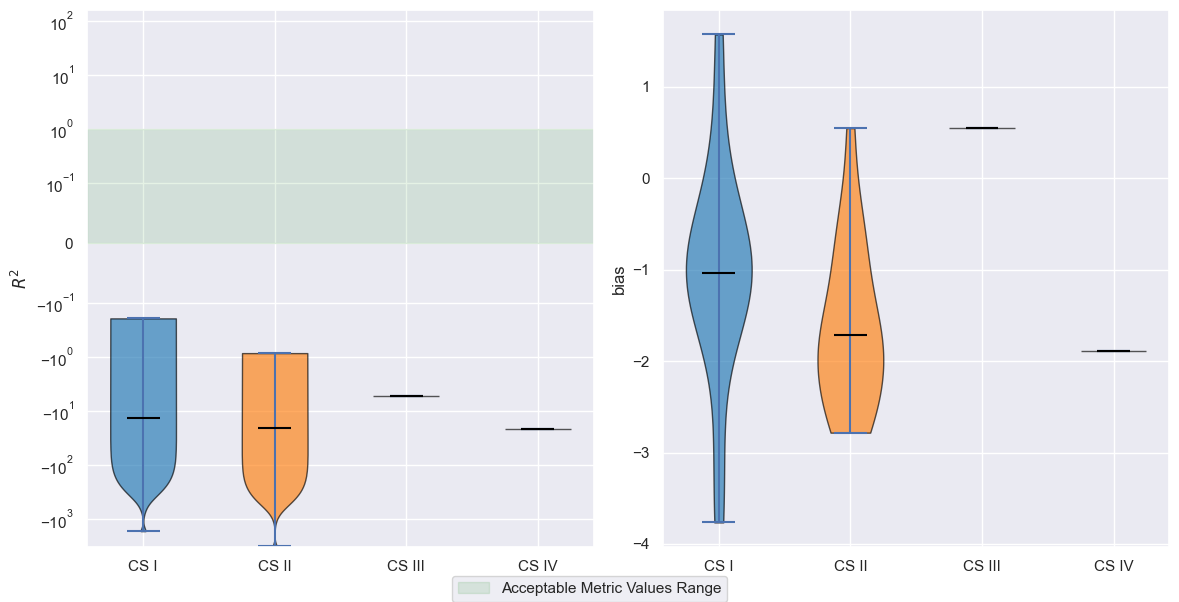

In [ ]:
from matplotlib.gridspec import GridSpec
x = (["CS I", "CS II", "CS III", "CS IV"], [1, 2, 3, 4])

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
ax1, ax2 = axs

cs_colors = ["tab:blue", "tab:orange", "tab:purple", "tab:red"]

# helper to color each violin body independently

def style_violins(parts, colors):
    for body, color in zip(parts["bodies"], colors):
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_alpha(0.65)
    if "cmedians" in parts:
        parts["cmedians"].set_color("black")


parts2 = ax1.violinplot([
    csi_ph["R"],
    csii_ph["R"],
    csiii_ph["R"],
    cdiv_ph["R"],
], showmedians=True)
style_violins(parts2, cs_colors)
ax1.set_ylabel("$R^2$")
ax1.axhspan(0, 1, alpha=0.1, color="green")
ax1.set_xticks(x[1])
ax1.set_xticklabels(x[0])

parts3 = ax2.violinplot([
    csi_ph["bias"],
    csii_ph["bias"],
    csiii_ph["bias"],
    cdiv_ph["bias"],
], showmedians=True)
style_violins(parts3, cs_colors)
ax2.set_ylabel("bias")
ax2.set_xticks(x[1])
ax2.set_xticklabels(x[0])

fig.legend(handles=[green_patch], loc="lower center", borderaxespad=0.)
plt.tight_layout()
# after creating the violins
linthresh = 0.1           # adjust to the smallest meaningful scale in your data
for ax in (ax1, ax):
    ax.set_yscale("symlog", linthresh=linthresh);

ValueError: zero-size array to reduction operation minimum which has no identity

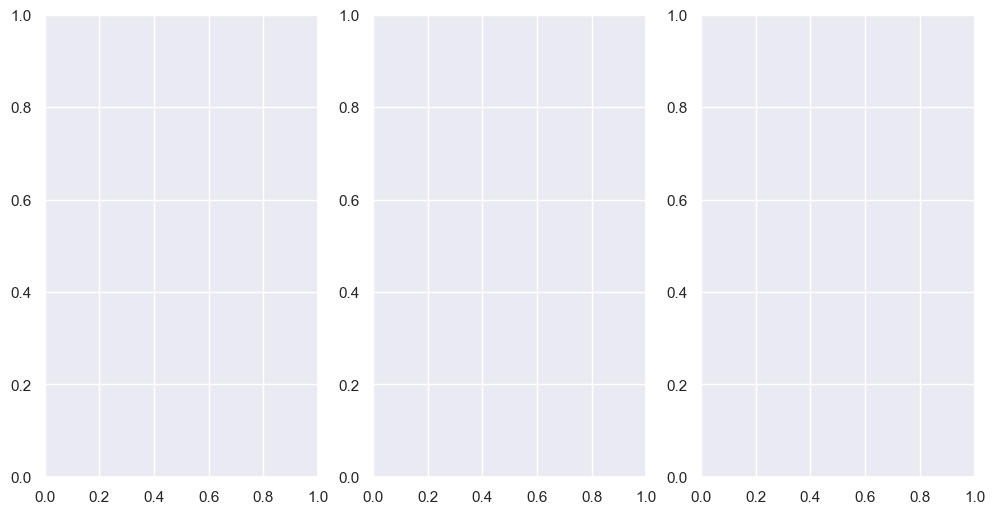

In [ ]:
x = (["CS I", "CS II", "CS III", "CS IV"], [1, 2, 3, 4])

fig, axs = plt.subplots(1, 3, figsize=(12, 6))
ax1, ax2, ax3 = axs

cs_colors = ["tab:blue", "tab:orange", "tab:purple", "tab:red"]

parts1 = ax1.violinplot([
    csi_fe_dis["KGE"],
    csii_fe_dis["KGE"],
    csiii_fe_dis["KGE"],
    cdiv_fe_dis["KGE"],
], showmedians=True)
style_violins(parts1, cs_colors)
ax1.set_ylabel("KGE")
ax1.axhspan(-0.41, 1, alpha=0.1, color="green")
ax1.set_xticks(x[1])
ax1.set_xticklabels(x[0])

parts2 = ax2.violinplot([
    csi_fe_dis["R"],
    csii_fe_dis["R"],
    csiii_fe_dis["R"],
    cdiv_fe_dis["R"],
], showmedians=True)
style_violins(parts2, cs_colors)
ax2.set_ylabel("$R^2$")
ax2.axhspan(0, 1, alpha=0.1, color="green")
ax2.set_xticks(x[1])
ax2.set_xticklabels(x[0])

parts3 = ax3.violinplot([
    csi_fe_dis["bias"],
    csii_fe_dis["bias"],
    csiii_fe_dis["bias"],
    cdiv_fe_dis["bias"],
], showmedians=True)
style_violins(parts3, cs_colors)
ax3.set_ylabel("bias")
ax3.set_xticks(x[1])
ax3.set_xticklabels(x[0])

fig.legend(handles=[green_patch], loc="lower center", borderaxespad=0.)
plt.tight_layout()
# after creating the violins
linthresh = 0.1           # adjust to the smallest meaningful scale in your data
for ax in (ax1, ax2):
    ax.set_yscale("symlog", linthresh=linthresh);

In [ ]:
x = (["CS I", "CS III", "CS IV"], [1, 2, 3, ])

fig, axs = plt.subplots(1, 3, figsize=(12, 6))
ax1, ax2, ax3 = axs

cs_colors = ["tab:blue", "tab:orange", "tab:purple", "tab:red"]

parts1 = ax1.violinplot([
    csi_fe_dis["KGE"],
    csiii_fe_dis["KGE"],
    cdiv_fe_dis["KGE"],
], showmedians=True)
style_violins(parts1, cs_colors)
ax1.set_ylabel("KGE")
ax1.axhspan(-0.41, 1, alpha=0.1, color="green")
ax1.set_xticks(x[1])
ax1.set_xticklabels(x[0])

parts2 = ax2.violinplot([
    csi_fe_dis["R"],
    csiii_fe_dis["R"],
    cdiv_fe_dis["R"],
], showmedians=True)
style_violins(parts2, cs_colors)
ax2.set_ylabel("$R^2$")
ax2.axhspan(0, 1, alpha=0.1, color="green")
ax2.set_xticks(x[1])
ax2.set_xticklabels(x[0])

parts3 = ax3.violinplot([
    csi_fe_dis["bias"],
    csiii_fe_dis["bias"],
    cdiv_fe_dis["bias"],
], showmedians=True)
style_violins(parts3, cs_colors)
ax3.set_ylabel("bias")
ax3.set_xticks(x[1])
ax3.set_xticklabels(x[0])

fig.legend(handles=[green_patch], loc="lower center", borderaxespad=0.)
plt.tight_layout()


In [ ]:
x = (["CS III"], [1])

fig, axs = plt.subplots(1, 3, figsize=(12, 6))
ax1, ax2, ax3 = axs

cs_colors = ["tab:purple"]

parts1 = ax1.violinplot([
    csiii_fe_tot["KGE"],
], showmedians=True)
style_violins(parts1, cs_colors)
ax1.set_ylabel("KGE")
ax1.axhspan(-0.41, 1, alpha=0.1, color="green")
ax1.set_xticks(x[1])
ax1.set_xticklabels(x[0])

parts2 = ax2.violinplot([
    csiii_fe_tot["R"],
], showmedians=True)
style_violins(parts2, cs_colors)
ax2.set_ylabel("R")
ax2.axhspan(0, 1, alpha=0.1, color="green")
ax2.set_xticks(x[1])
ax2.set_xticklabels(x[0])

parts3 = ax3.violinplot([
    csiii_fe_tot["bias"],
], showmedians=True)
style_violins(parts3, cs_colors)
ax3.set_ylabel("bias")
ax3.set_xticks(x[1])
ax3.set_xticklabels(x[0])

fig.legend(handles=[green_patch], loc="lower center", borderaxespad=0.)
plt.tight_layout();

In [ ]:
def _get_amd_var_names(caravan_var):
    if caravan_var == "pH":
        return ["pH"]
    if caravan_var == "Fe-Dis":
        return ["ferrous_iron", "ferric_iron"]
    if caravan_var == "Fe-Tot":
        return ["ferrous_iron", "ferric_iron", "ferric_oxyhydroxide"]
    raise ValueError(f"Unknown caravan variable: {caravan_var}")


def extract_case_pairs(case_name, case_csv, amd_path, caravan_path,
                       caravan_var, resample_freq="W", tol_days=14):
    matches = pd.read_csv(case_csv)
    matches = matches.dropna(subset=["wqms_id", "cell_lat", "cell_lon"])
    matches["wqms_id"] = matches["wqms_id"].astype(str)

    amd = xr.open_dataset(amd_path, chunks={})
    caravan = xr.open_dataset(caravan_path, engine="zarr", chunks={})

    vars_ = _get_amd_var_names(caravan_var)
    obs = caravan[caravan_var].sel(wqms_id=matches["wqms_id"].unique())
    if resample_freq:
        obs = obs.resample(time=resample_freq).mean(skipna=True)
    obs_df = obs.to_series().rename("observed").reset_index()
    obs_df["time"] = pd.to_datetime(obs_df["time"])

    model_frames = []
    cell_df = matches[["wqms_id", "cell_lat", "cell_lon"]].drop_duplicates()
    for _, row in cell_df.iterrows():
        if len(vars_) == 1:
            data = amd[vars_[0]].sel(lat=row["cell_lat"], lon=row["cell_lon"], method="nearest")
        else:
            data = sum(
                amd[v].sel(lat=row["cell_lat"], lon=row["cell_lon"], method="nearest")
                * ((55.845 / 106.87) if v == "ferric_oxyhydroxide" else 1)
                for v in vars_
            )

        model_df = data.to_series().rename("modelled").reset_index()
        model_df["time"] = pd.to_datetime(model_df["time"])
        model_df["wqms_id"] = row["wqms_id"]
        model_frames.append(model_df)

    amd.close()
    caravan.close()

    model_df = pd.concat(model_frames, ignore_index=True)
    model_df = model_df.sort_values(["wqms_id", "time"]).reset_index(drop=True)
    obs_df = obs_df.sort_values(["wqms_id", "time"]).reset_index(drop=True)

    paired_frames = []
    for wqms_id, obs_group in obs_df.groupby("wqms_id"):
        model_group = model_df[model_df["wqms_id"] == wqms_id]
        if model_group.empty:
            continue
        obs_group = obs_group.sort_values("time")
        model_group = model_group.sort_values("time")
        paired = pd.merge_asof(
            obs_group,
            model_group,
            on="time",
            direction="nearest",
            tolerance=pd.Timedelta(f"{tol_days}D")
        )
        paired_frames.append(paired)

    if paired_frames:
        paired = pd.concat(paired_frames, ignore_index=True)
    else:
        paired = pd.DataFrame(columns=["wqms_id", "time", "observed", "modelled"])

    paired = paired.dropna(subset=["observed", "modelled"])
    paired["case_study"] = case_name
    return paired


def plot_variable_corr_all_cases(variable_name, case_infos, resample_freq="W", tol_days=14, 
                                 show_kge=False, log_scale=False, text_position="upper left",
                                 unit = "", output = None):
    frames = []
    for case_name, case_csv, amd_path in case_infos:
        frames.append(extract_case_pairs(
            case_name,
            case_csv,
            amd_path,
            "../data/validation data/Caravan-Qual_lite.zarr",
            variable_name,
            resample_freq=resample_freq,
            tol_days=tol_days
        ))

    all_df = pd.concat(frames, ignore_index=True)
    if all_df.empty:
        raise ValueError("No paired observations were found for any case study.")

    mn = min(all_df["observed"].min(), all_df["modelled"].min())
    mx = max(all_df["observed"].max(), all_df["modelled"].max())

    fig = plt.figure(figsize=(8, 8))
    case_palette = {
        "CSI": "blue",
        "CSII": "orange",
        "CSIII": "purple",
        "CSIV": "red",
    }
    sns.scatterplot(
        data=all_df,
        x="modelled",
        y="observed",
        hue="case_study",
        palette=case_palette,
        alpha=0.6
    )
    plt.legend(title="", framealpha=0.7, facecolor="white", edgecolor="none", fontsize=10)
    plt.plot([mn, mx], [mn, mx], "k--", linewidth=1)
    plt.xlabel(f"Modelled {unit}")
    plt.ylabel(f"Observed {unit}")
    print(f"Modelled vs Observed: {variable_name} (all case studies)")
    if log_scale:
        plt.xscale("log")
        plt.yscale("log")
    plt.xlim(mn, mx)
    plt.ylim(mn, mx)

    summary_lines = []
    for case_name, group in all_df.groupby("case_study"):
        r2 = np.corrcoef(group["observed"], group["modelled"])[0, 1] ** 2
        if show_kge:
            obs_da = xr.DataArray(group["observed"].values, coords={"time": group["time"]}, dims=["time"])
            model_da = xr.DataArray(group["modelled"].values, coords={"time": group["time"]}, dims=["time"])
            kge_val = float(kge(model_da, obs_da).item())
            summary_lines.append(f"{case_name}: $R^2$={r2:.2f}, KGE={kge_val:.2f}")
        else:
            summary_lines.append(f"{case_name}: $R^2$={r2:.2f}")

    # Map text_position to coordinates and alignment
    position_map = {
        "upper left": {"x": 0.02, "y": 0.98, "va": "top", "ha": "left"},
        "upper right": {"x": 0.98, "y": 0.98, "va": "top", "ha": "right"},
        "lower left": {"x": 0.02, "y": 0.02, "va": "bottom", "ha": "left"},
        "lower right": {"x": 0.98, "y": 0.02, "va": "bottom", "ha": "right"},
    }
    
    if text_position not in position_map:
        raise ValueError(f"text_position must be one of {list(position_map.keys())}, got '{text_position}'")
    
    pos = position_map[text_position]
    plt.gca().text(
        pos["x"],
        pos["y"],
        "\n".join(summary_lines),
        transform=plt.gca().transAxes,
        verticalalignment=pos["va"],
        horizontalalignment=pos["ha"],
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    if output:
        fig.savefig(output, dpi = 300, bbox_inches = "tight")

Modelled vs Observed: Fe-Dis (all case studies)


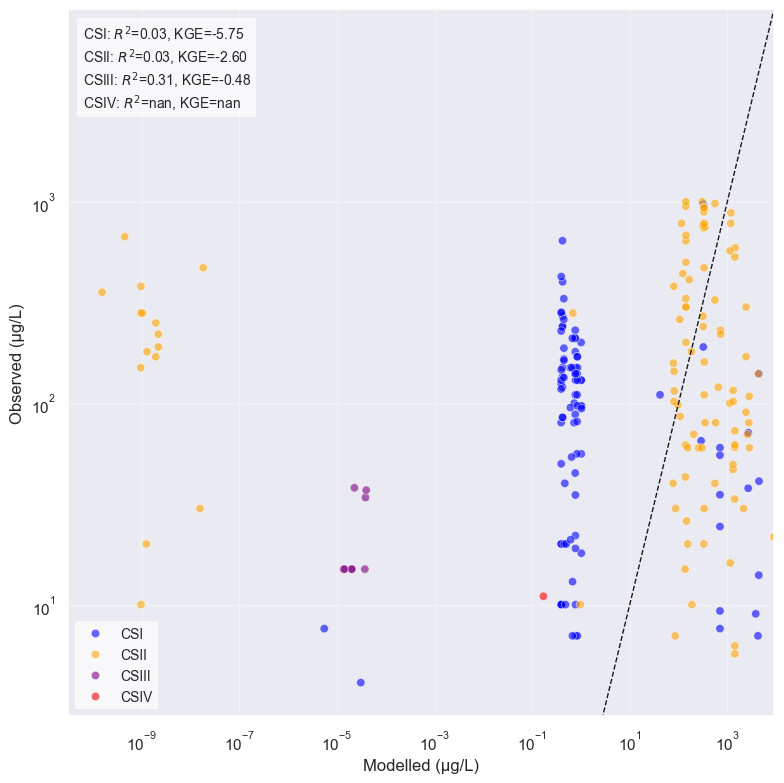

In [ ]:
case_infos = [
    ("CSI",  "../data/validation data/CSI/metrics_Fe-Dis.csv",  "../data/validation data/AMDFLOW_CSI_1960-2015_W.nc"),
    ("CSII", "../data/validation data/CSII/metrics_Fe-Dis.csv", "../data/validation data/AMDFLOW_CSII_1960-2015_W.nc"),
    ("CSIII", "../data/validation data/CSIII/metrics_Fe-Dis.csv", "../data/validation data/AMDFLOW_CSIII_1960-2015_W.nc"),
    ("CSIV", "../data/validation data/CSIV/metrics_Fe-Dis.csv", "../data/validation data/AMDFLOW_CSIV_1960-2015_W.nc"),
]

plot_variable_corr_all_cases("Fe-Dis", case_infos, resample_freq="W", show_kge=True, log_scale=True, unit = "(µg/L)",
                             output = "../images/corr_fe_dis.png")

Modelled vs Observed: pH (all case studies)


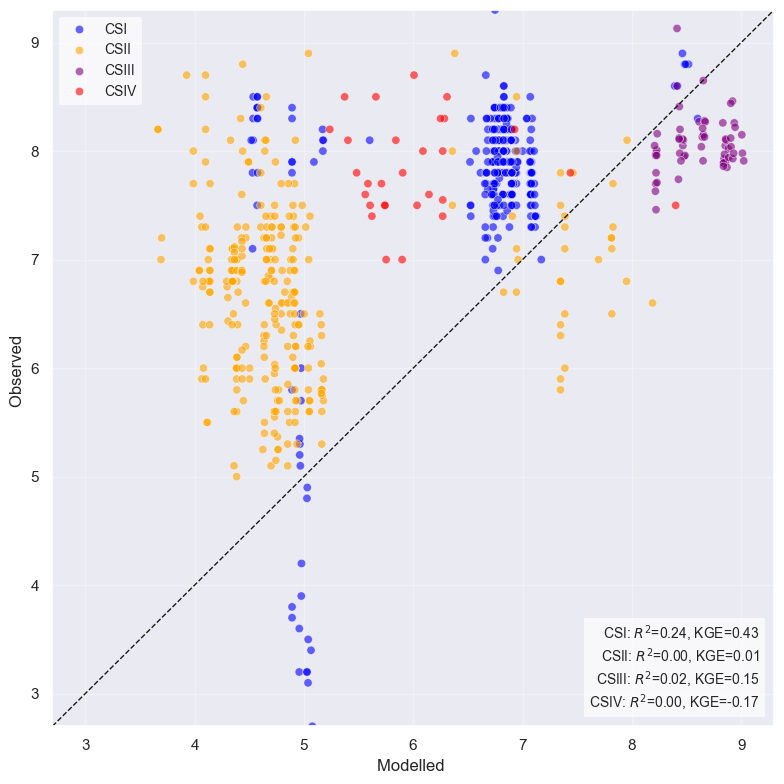

In [ ]:
case_infos = [
    ("CSI",  "../data/validation data/CSI/metrics_pH.csv",  "../data/validation data/AMDFLOW_CSI_1960-2015_W.nc"),
    ("CSII", "../data/validation data/CSII/metrics_pH.csv", "../data/validation data/AMDFLOW_CSII_1960-2015_W.nc"),
    ("CSIII", "../data/validation data/CSIII/metrics_pH.csv", "../data/validation data/AMDFLOW_CSIII_1960-2015_W.nc"),
    ("CSIV", "../data/validation data/CSIV/metrics_pH.csv", "../data/validation data/AMDFLOW_CSIV_1960-2015_W.nc"),
]

plot_variable_corr_all_cases("pH", case_infos, resample_freq="W", show_kge=True, text_position= "lower right",
                             output = "../images/corr_ph.png")

In [ ]:
case_infos = [
    ("CSI",  "../data/validation data/CSI/metrics_Fe-Tot.csv",  "../data/validation data/AMDFLOW_CSI_1960-2015_W.nc"),
    ("CSII", "../data/validation data/CSII/metrics_Fe-Tot.csv", "../data/validation data/AMDFLOW_CSII_1960-2015_W.nc"),
    ("CSIII", "../data/validation data/CSIII/metrics_Fe-Tot.csv", "../data/validation data/AMDFLOW_CSIII_1960-2015_W.nc"),
    ("CSIV", "../data/validation data/CSIV/metrics_Fe-Tot.csv", "../data/validation data/AMDFLOW_CSIV_1960-2015_W.nc"),
]

plot_variable_corr_all_cases("Fe-Tot", case_infos, resample_freq="W")

ValueError: No objects to concatenate

In [ ]:
def get_var_from_amd(vars):
    csi_amd = xr.open_dataset("../data/validation data/AMDFLOW_CSI_1960-2015_W.nc")
    csi_var = csi_amd[vars[0]]
    csi_amd.close()

    csii_amd = xr.open_dataset("../data/validation data/AMDFLOW_CSII_1960-2015_W.nc")
    csii_var = csii_amd[vars[1]]
    csii_amd.close()

    csiii_amd = xr.open_dataset("../data/validation data/AMDFLOW_CSIII_1960-2015_W.nc")
    csiii_var = csiii_amd[vars[2]]
    csiii_amd.close()

    csiv_amd = xr.open_dataset("../data/validation data/AMDFLOW_CSIV_1960-2015_W.nc")
    csiv_var = csiv_amd[vars[3]]
    csiv_amd.close()
    return csi_var, csii_var, csiii_var, csiv_var

In [ ]:
vars = ["ferric_iron", "ferrous_iron", "ferric_oxyhydroxide", "bedload_storage"]
csi_var, csii_var, csiii_var, csiv_var = get_var_from_amd(vars)

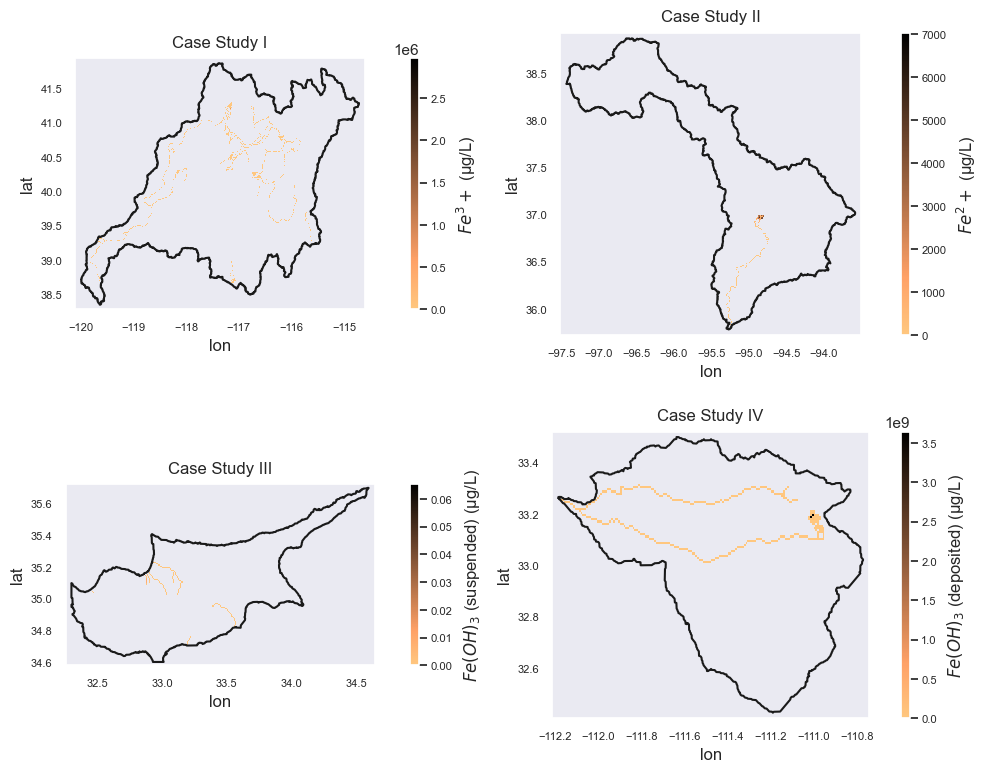

In [ ]:
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

bar_vars = [
    "$Fe^3+$",
    "$Fe^2+$",
    "$Fe(OH)_3$ (suspended)",
    "$Fe(OH)_3$ (deposited)",
]
units = ["µg/L"] * 4
titles = ["Case Study I", "Case Study II", "Case Study III", "Case Study IV"]

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axes = axs.flatten()
vars_ = [csi_var, csii_var, csiii_var, csiv_var]
aois = [csi_aoi, csii_aoi, csiii_aoi, csiv_aoi]

for ax, var, bar_title, unit, aoi, plot_title in zip(axes, vars_, bar_vars, units, aois, titles):
    arr = var.isel(time=-1).where(var.isel(time=-1) > 0)
    mesh = arr.plot(ax=ax, add_colorbar=False, cmap="copper_r")

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2.5%", pad=0.01)
    cb = fig.colorbar(mesh, cax=cax)
    cb.set_label(f"{bar_title} ({unit})", labelpad=6)
    cb.ax.tick_params(labelsize=8, pad=2)

    ax.set_title(plot_title, pad=8)
    ax.set_aspect("equal")
    ax.tick_params(axis="both", labelsize=8)

    aoi.boundary.plot(ax=ax, edgecolor="k")

    bounds = aoi.total_bounds
    dx = bounds[2] - bounds[0]
    dy = bounds[3] - bounds[1]
    pad = 0.02
    ax.set_xlim(bounds[0] - dx * pad, bounds[2] + dx * pad)
    ax.set_ylim(bounds[1] - dy * pad, bounds[3] + dy * pad)

fig.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95,
                    wspace=0.10, hspace=0.12)
fig.tight_layout()
fig.savefig("../images/plumes.png", dpi = 300, bbox_inches="tight")


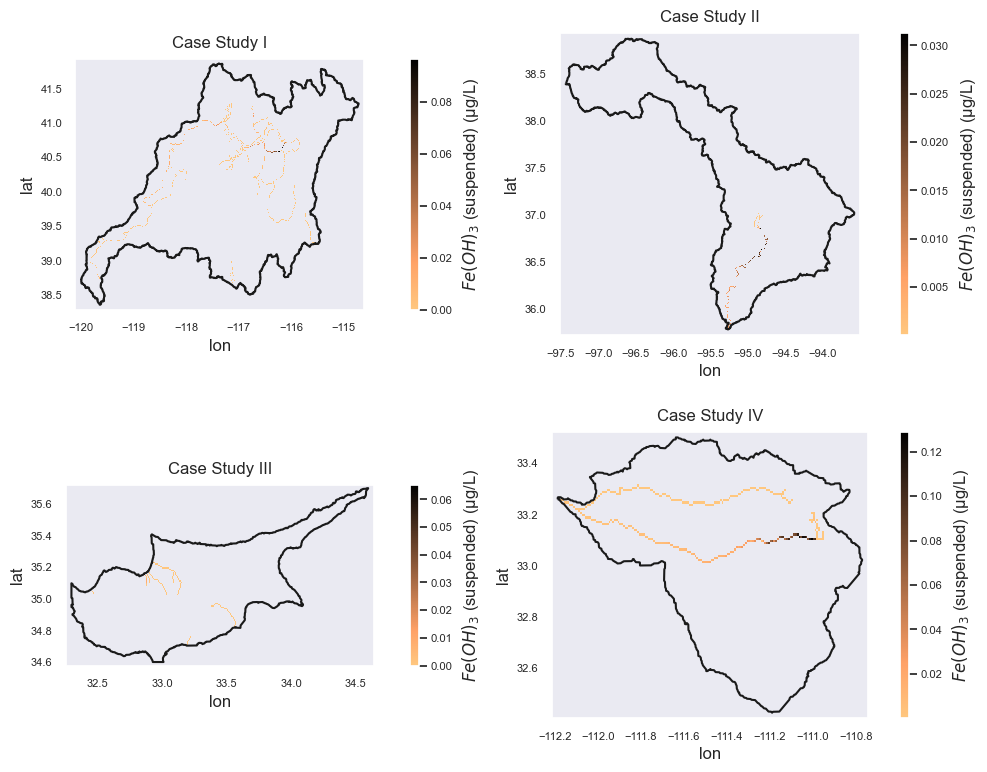

In [ ]:
vars = ["ferric_oxyhydroxide", "ferric_oxyhydroxide", "ferric_oxyhydroxide", "ferric_oxyhydroxide"]
csi_var, csii_var, csiii_var, csiv_var = get_var_from_amd(vars)

bar_vars = [
    "$Fe(OH)_3$ (suspended)",
] * 4
units = ["µg/L"] * 4
titles = ["Case Study I", "Case Study II", "Case Study III", "Case Study IV"]

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axes = axs.flatten()
vars_ = [csi_var, csii_var, csiii_var, csiv_var]
aois = [csi_aoi, csii_aoi, csiii_aoi, csiv_aoi]

for ax, var, bar_title, unit, aoi, plot_title in zip(axes, vars_, bar_vars, units, aois, titles):
    arr = var.isel(time=-1).where(var.isel(time=-1) > 0)
    mesh = arr.plot(ax=ax, add_colorbar=False, cmap="copper_r")

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2.5%", pad=0.01)
    cb = fig.colorbar(mesh, cax=cax)
    cb.set_label(f"{bar_title} ({unit})", labelpad=6)
    cb.ax.tick_params(labelsize=8, pad=2)

    ax.set_title(plot_title, pad=8)
    ax.set_aspect("equal")
    ax.tick_params(axis="both", labelsize=8)

    aoi.boundary.plot(ax=ax, edgecolor="k")

    bounds = aoi.total_bounds
    dx = bounds[2] - bounds[0]
    dy = bounds[3] - bounds[1]
    pad = 0.02
    ax.set_xlim(bounds[0] - dx * pad, bounds[2] + dx * pad)
    ax.set_ylim(bounds[1] - dy * pad, bounds[3] + dy * pad)

fig.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95,
                    wspace=0.10, hspace=0.12)
fig.tight_layout()

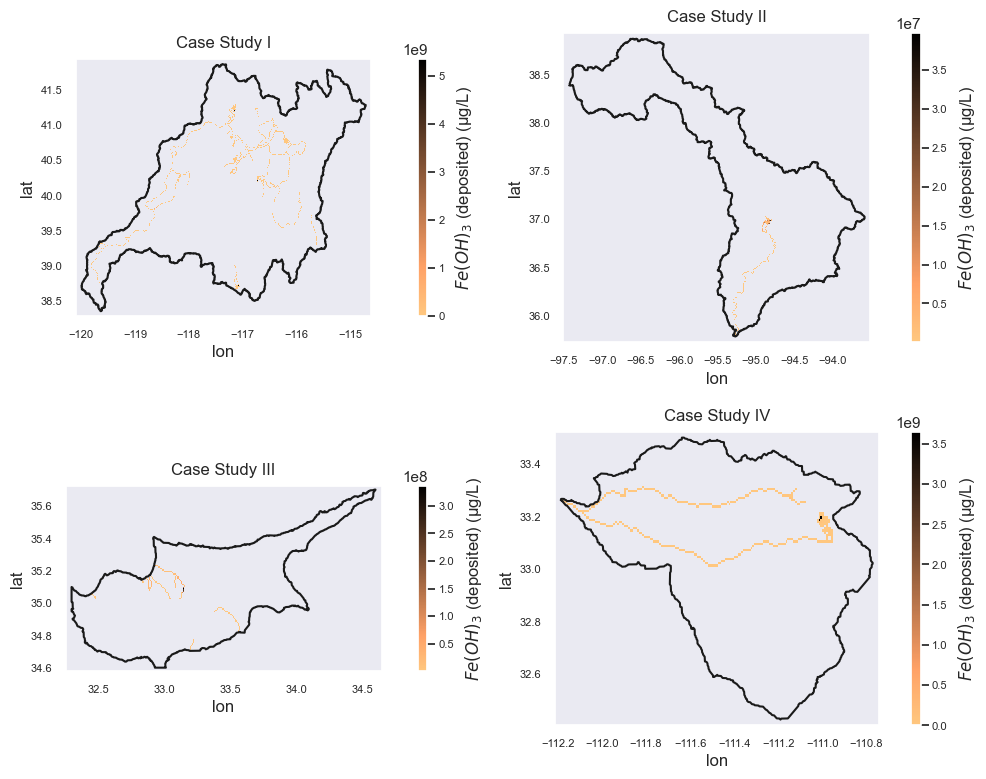

In [ ]:
vars = ["bedload_storage"] * 4
csi_var, csii_var, csiii_var, csiv_var = get_var_from_amd(vars)

bar_vars = [
    "$Fe(OH)_3$ (deposited)",
] * 4
units = ["µg/L"] * 4
titles = ["Case Study I", "Case Study II", "Case Study III", "Case Study IV"]

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axes = axs.flatten()
vars_ = [csi_var, csii_var, csiii_var, csiv_var]
aois = [csi_aoi, csii_aoi, csiii_aoi, csiv_aoi]

for ax, var, bar_title, unit, aoi, plot_title in zip(axes, vars_, bar_vars, units, aois, titles):
    arr = var.isel(time=-1).where(var.isel(time=-1) > 0)
    mesh = arr.plot(ax=ax, add_colorbar=False, cmap="copper_r")

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2.5%", pad=0.01)
    cb = fig.colorbar(mesh, cax=cax)
    cb.set_label(f"{bar_title} ({unit})", labelpad=6)
    cb.ax.tick_params(labelsize=8, pad=2)

    ax.set_title(plot_title, pad=8)
    ax.set_aspect("equal")
    ax.tick_params(axis="both", labelsize=8)

    aoi.boundary.plot(ax=ax, edgecolor="k")

    bounds = aoi.total_bounds
    dx = bounds[2] - bounds[0]
    dy = bounds[3] - bounds[1]
    pad = 0.02
    ax.set_xlim(bounds[0] - dx * pad, bounds[2] + dx * pad)
    ax.set_ylim(bounds[1] - dy * pad, bounds[3] + dy * pad)

fig.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95,
                    wspace=0.10, hspace=0.12)
fig.tight_layout()

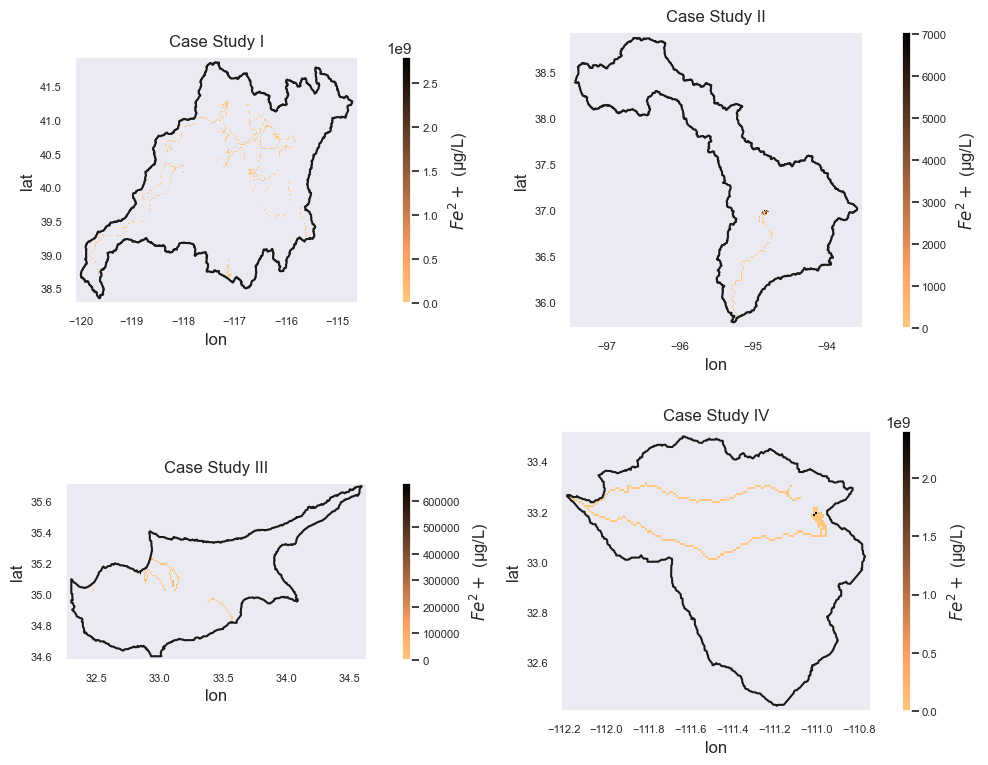

In [ ]:
vars = ["ferrous_iron"] * 4
csi_var, csii_var, csiii_var, csiv_var = get_var_from_amd(vars)

bar_vars = [
    "$Fe^2+$",
] * 4
units = ["µg/L"] * 4
titles = ["Case Study I", "Case Study II", "Case Study III", "Case Study IV"]

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axes = axs.flatten()
vars_ = [csi_var, csii_var, csiii_var, csiv_var]
aois = [csi_aoi, csii_aoi, csiii_aoi, csiv_aoi]

for ax, var, bar_title, unit, aoi, plot_title in zip(axes, vars_, bar_vars, units, aois, titles):
    arr = var.isel(time=-1).where(var.isel(time=-1) > 0)
    mesh = arr.plot(ax=ax, add_colorbar=False, cmap="copper_r")

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2.5%", pad=0.01)
    cb = fig.colorbar(mesh, cax=cax)
    cb.set_label(f"{bar_title} ({unit})", labelpad=6)
    cb.ax.tick_params(labelsize=8, pad=2)

    ax.set_title(plot_title, pad=8)
    ax.set_aspect("equal")
    ax.tick_params(axis="both", labelsize=8)

    aoi.boundary.plot(ax=ax, edgecolor="k")

    bounds = aoi.total_bounds
    dx = bounds[2] - bounds[0]
    dy = bounds[3] - bounds[1]
    pad = 0.02
    ax.set_xlim(bounds[0] - dx * pad, bounds[2] + dx * pad)
    ax.set_ylim(bounds[1] - dy * pad, bounds[3] + dy * pad)

fig.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95,
                    wspace=0.10, hspace=0.12)
fig.tight_layout()

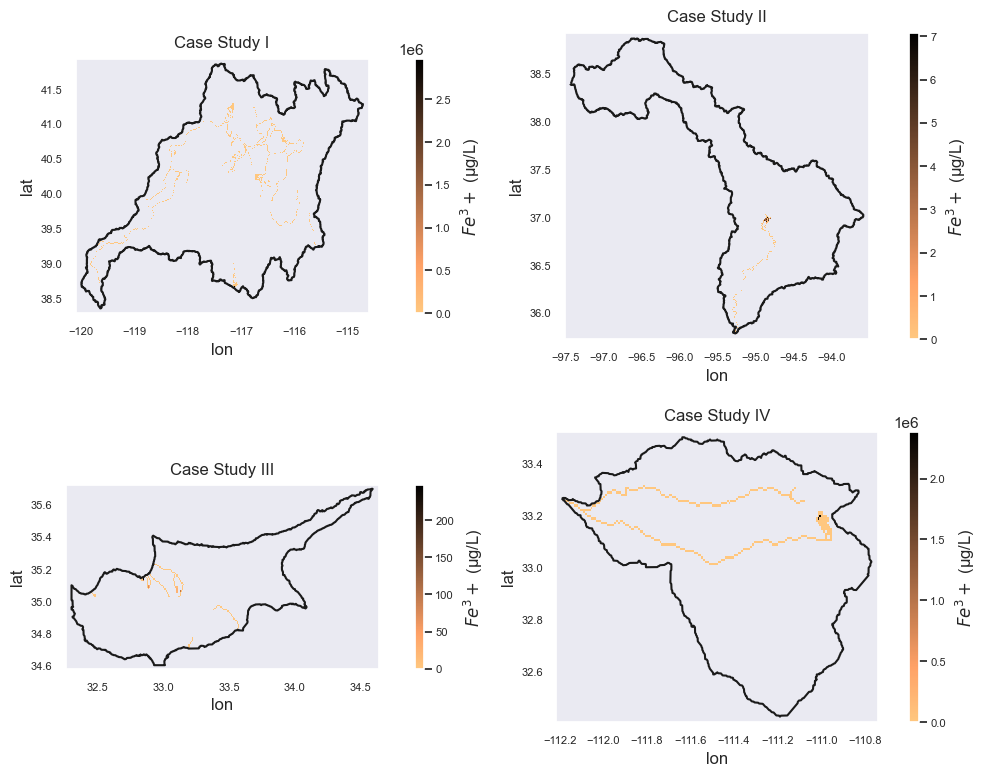

In [ ]:
vars = ["ferric_iron"] * 4
csi_var, csii_var, csiii_var, csiv_var = get_var_from_amd(vars)

bar_vars = [
    "$Fe^3+$",
] * 4
units = ["µg/L"] * 4
titles = ["Case Study I", "Case Study II", "Case Study III", "Case Study IV"]

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axes = axs.flatten()
vars_ = [csi_var, csii_var, csiii_var, csiv_var]
aois = [csi_aoi, csii_aoi, csiii_aoi, csiv_aoi]

for ax, var, bar_title, unit, aoi, plot_title in zip(axes, vars_, bar_vars, units, aois, titles):
    arr = var.isel(time=-1).where(var.isel(time=-1) > 0)
    mesh = arr.plot(ax=ax, add_colorbar=False, cmap="copper_r")

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2.5%", pad=0.01)
    cb = fig.colorbar(mesh, cax=cax)
    cb.set_label(f"{bar_title} ({unit})", labelpad=6)
    cb.ax.tick_params(labelsize=8, pad=2)

    ax.set_title(plot_title, pad=8)
    ax.set_aspect("equal")
    ax.tick_params(axis="both", labelsize=8)

    aoi.boundary.plot(ax=ax, edgecolor="k")

    bounds = aoi.total_bounds
    dx = bounds[2] - bounds[0]
    dy = bounds[3] - bounds[1]
    pad = 0.02
    ax.set_xlim(bounds[0] - dx * pad, bounds[2] + dx * pad)
    ax.set_ylim(bounds[1] - dy * pad, bounds[3] + dy * pad)

fig.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95,
                    wspace=0.10, hspace=0.12)
fig.tight_layout()

Loaded Natural Earth 110 m geometry  (column: ISO_A3_EH)

Matched 126 / 129 countries with localities to geometry.

Saved PNG  → ../images/pyrite_map.png  (300 dpi)
Saved PDF  → ../images/pyrite_map.pdf  (vector)


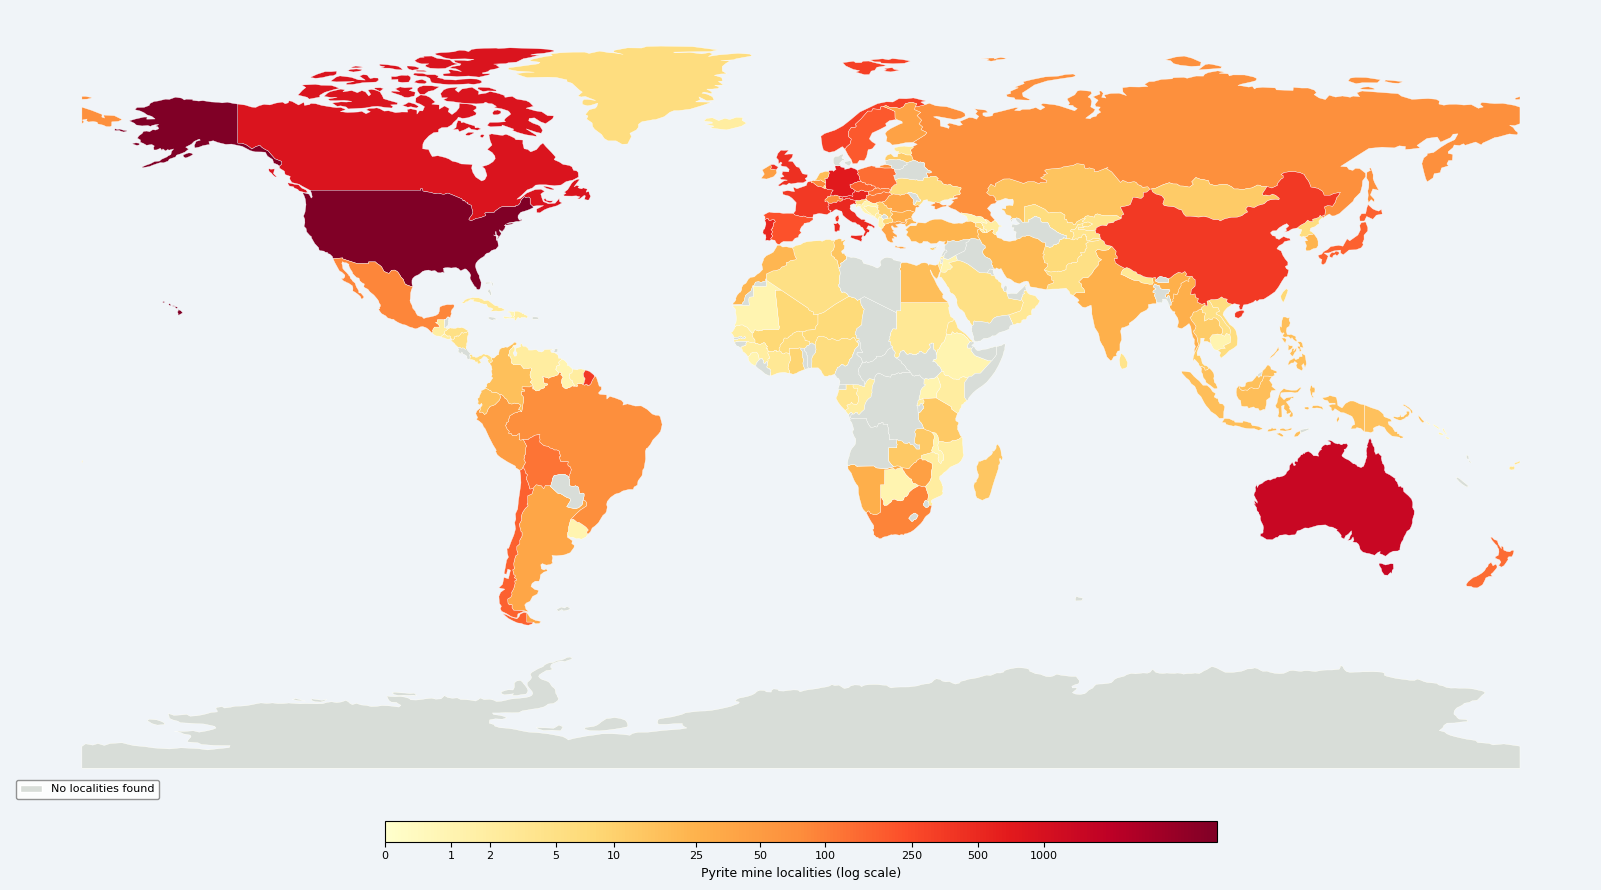

In [ ]:
"""
pyrite_static_map.py
====================
Reads summary.csv (produced by pyrite_global_heatmap.py) and saves a
publication-quality static choropleth map using geopandas + matplotlib.

Requirements
------------
    pip install geopandas matplotlib pandas numpy

Output
------
    pyrite_map.png  (300 dpi — suitable for publication / posters)
    pyrite_map.pdf  (vector — scalable for LaTeX / Illustrator)
"""

import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import geopandas as gpd

# suppress the geopandas deprecation warning for the bundled dataset
warnings.filterwarnings("ignore", category=DeprecationWarning)


# =============================================================================
# 1.  Load locality counts
# =============================================================================

def load_summary(csv_path: str = "../data/mindat_data/summary.csv") -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    # clip any error sentinels (-1) to 0
    df["count"] = df["count"].clip(lower=0)
    return df[["iso3", "country", "count"]]


# =============================================================================
# 2.  Load world geometry
# =============================================================================

def load_world() -> tuple[gpd.GeoDataFrame, str]:
    """
    Returns (world_geodataframe, iso_column_name).

    Tries three sources in order of preference:
      1. Natural Earth 110 m countries via direct URL  (most detail, current)
      2. geopandas bundled naturalearth_lowres          (always available)
    """
    # ── Option 1: download Natural Earth 110 m from S3 ────────────────────────
    NE_URL = (
        "https://naturalearth.s3.amazonaws.com/110m_cultural/"
        "ne_110m_admin_0_countries.zip"
    )
    try:
        world = gpd.read_file(NE_URL)
        # The 110 m file uses ISO_A3_EH which is more complete than ISO_A3
        # (ISO_A3 has '-99' for Kosovo, Norway etc. in older versions)
        iso_col = "ISO_A3_EH" if "ISO_A3_EH" in world.columns else "ISO_A3"
        print(f"Loaded Natural Earth 110 m geometry  (column: {iso_col})")
        return world, iso_col

    except Exception as exc:
        print(f"Could not fetch 110 m file ({exc}); falling back to bundled data.")

    # ── Option 2: bundled low-res dataset ─────────────────────────────────────
    world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
    print("Loaded bundled naturalearth_lowres geometry  (column: iso_a3)")
    return world, "iso_a3"


# =============================================================================
# 3.  Merge geometry with locality counts
# =============================================================================

def merge_data(
    world:   gpd.GeoDataFrame,
    iso_col: str,
    summary: pd.DataFrame,
) -> gpd.GeoDataFrame:
    """
    Left-join world geometry with summary counts on the ISO-alpha3 code.
    Countries with no match (Antarctica, disputed territories, …) get count=0.
    """
    # Some Natural Earth entries have '-99' instead of a real ISO code.
    # We can still match them by country name as a fallback.
    merged = world.merge(
        summary[["iso3", "count"]],
        left_on=iso_col,
        right_on="iso3",
        how="left",
    )
    merged["count"] = merged["count"].fillna(0).astype(int)
    return merged


# =============================================================================
# 4.  Plot
# =============================================================================

def plot_static_map(
    merged:     gpd.GeoDataFrame,
    log_scale:  bool = True,
    output_png: str  = "../images/pyrite_map.png",
    dpi:        int  = 300,
) -> None:
    """
    Saves a static choropleth world map.

    Parameters
    ----------
    log_scale : bool
        Use log₁₀(count + 1) colour axis — recommended for skewed data.
    dpi : int
        Resolution for the PNG output (300 = publication quality).
    """
    fig, ax = plt.subplots(figsize=(18, 9), facecolor="#f0f4f8")
    ax.set_facecolor("#d6e8f5")          # ocean colour

    cmap = mpl.colormaps["YlOrRd"]

    # ── Build colour values ────────────────────────────────────────────────────
    if log_scale:
        merged["_c"] = np.log10(merged["count"] + 1)
    else:
        merged["_c"] = merged["count"].astype(float)

    vmin, vmax = 0.0, merged["_c"].max()
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # ── Countries with data ────────────────────────────────────────────────────
    merged.plot(
        column="_c",
        cmap=cmap,
        norm=norm,
        ax=ax,
        edgecolor="white",
        linewidth=0.25,
        missing_kwds={"color": "#c8d6c8", "label": "No data"},  # fallback
    )

    # ── Countries with zero localities (count == 0) ────────────────────────────
    # These are matched rows but genuinely have no data — paint them light grey
    # so they're visually distinct from the ocean.
    zero_mask = merged["count"] == 0
    merged[zero_mask].plot(
        ax=ax,
        color="#d8ddd8",
        edgecolor="white",
        linewidth=0.25,
    )

    # ── Colour bar ─────────────────────────────────────────────────────────────
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(
        sm, ax=ax,
        orientation="horizontal",
        fraction=0.025,
        pad=0.02,
        aspect=40,
    )

    if log_scale:
        # Show real count values on the tick marks
        raw_ticks = [0, 1, 2, 5, 10, 25, 50, 100, 250, 500, 1000]
        # Keep only ticks within the actual data range
        max_raw = int(10 ** vmax - 1)
        raw_ticks = [t for t in raw_ticks if t <= max_raw]
        log_ticks = [np.log10(t + 1) for t in raw_ticks]

        cbar.set_ticks(log_ticks)
        cbar.set_ticklabels([str(t) for t in raw_ticks], fontsize=8)
        cbar.set_label("Pyrite mine localities (log scale)", fontsize=9)
    else:
        cbar.set_label("Pyrite mine localities", fontsize=9)

    # ── Labels & styling ───────────────────────────────────────────────────────
    ax.set_axis_off()

    # ── Legend patch for zero-count countries ──────────────────────────────────
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#d8ddd8", edgecolor="white", label="No localities found"),
    ]
    ax.legend(
        handles=legend_elements,
        loc="lower left",
        fontsize=8,
        framealpha=0.85,
        edgecolor="grey",
    )

    plt.tight_layout()

    # ── Save ───────────────────────────────────────────────────────────────────
    if output_png:
        fig.savefig(output_png, dpi=dpi, bbox_inches="tight")
        print(f"Saved PNG  → {output_png}  ({dpi} dpi)")

    plt.show()
    plt.close(fig)


# =============================================================================
# 5.  Entry point
# =============================================================================

if __name__ == "__main__":
    summary      = load_summary("../data/mindat_data/summary.csv")
    world, iso_col = load_world()
    merged       = merge_data(world, iso_col, summary)

    # Quick sanity check
    n_matched = (merged["count"] > 0).sum()
    n_total   = len(summary[summary["count"] > 0])
    print(f"\nMatched {n_matched} / {n_total} countries with localities to geometry.\n")

    plot_static_map(
        merged,
        log_scale=True,
        output_png="../images/pyrite_map.png",
        dpi=300,
    )